# Flare Source Paper — Data Coverage Analysis

Analysis of temporal coverage and data quality in `hq_nc70.parquet`.

In [1]:
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, scale_color_manual,
    scale_x_datetime, scale_y_log10,
    labs, theme_bw, theme, element_text, element_blank, facet_wrap
)

In [2]:
DATA_PATH = (
    "/Users/vkverma/research/harp_data"
    "/hmi_sharp_cea_720s/data/processed/nc68.parquet"
)
CADENCE = pd.Timedelta(minutes=12)

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df['HARPNUM'].nunique():,} HARPs")

Loaded 4,160,280 rows, 6,344 HARPs


## 1. Consecutive time differences

In [3]:
distinct_times = (
    df["T_REC"].drop_duplicates().sort_values().reset_index(drop=True)
)
print(f"Distinct T_REC values: {len(distinct_times):,}")
print(f"Earliest: {distinct_times.iloc[0]}")
print(f"Latest:   {distinct_times.iloc[-1]}")

diffs = distinct_times.diff()
gaps = diffs[diffs > CADENCE]
print(f"\nDiffs > 12 min: {len(gaps):,}")
print(f"Max gap: {diffs.max()}")
if len(gaps) > 0:
    gap_starts = distinct_times[gaps.index - 1].values
    gap_ends   = distinct_times[gaps.index].values
    gap_df = pd.DataFrame({
        "gap_start": gap_starts,
        "gap_end": gap_ends,
        "duration": gaps.values,
    })
    print("\nLargest 5 gaps:")
    display(gap_df.sort_values("duration", ascending=False).head())

Distinct T_REC values: 566,100
Earliest: 2010-05-01 00:00:00+00:00
Latest:   2024-08-21 23:48:00+00:00

Diffs > 12 min: 97
Max gap: 31 days 20:36:00

Largest 5 gaps:


,gap_start,gap_end,duration
68,2019-11-20 17:00:00,2019-12-22 13:36:00,31 days 20:36:00
72,2020-02-07 23:36:00,2020-03-07 11:12:00,28 days 11:36:00
65,2019-09-05 16:48:00,2019-10-01 15:12:00,25 days 22:24:00
64,2019-08-09 05:00:00,2019-09-01 03:12:00,22 days 22:12:00
66,2019-10-09 02:12:00,2019-10-31 22:12:00,22 days 20:00:00


## 2. Full 12-minute sequence — record coverage

In [4]:
t_start = distinct_times.iloc[0]
t_end   = distinct_times.iloc[-1]

full_seq = pd.date_range(start=t_start, end=t_end, freq=CADENCE, tz="UTC")
print(f"Full sequence length: {len(full_seq):,}")

times_set = set(distinct_times)
has_record = pd.Series(full_seq).isin(times_set).values

pct_record = has_record.mean() * 100
print(
    f"Times with a record: {has_record.sum():,} / "
    f"{len(full_seq):,} ({pct_record:.2f}%)"
)

Full sequence length: 627,240
Times with a record: 566,100 / 627,240 (90.25%)


## 3. Full sequence — high-quality record coverage

In [5]:
hq_times_set = set(df.loc[df["QUALITY"] == 0, "T_REC"].drop_duplicates())

has_hq_record = pd.Series(full_seq).isin(hq_times_set).values

pct_hq = has_hq_record.mean() * 100
print(
    f"Times with a high-quality record: {has_hq_record.sum():,} / "
    f"{len(full_seq):,} ({pct_hq:.2f}%)"
)

Times with a high-quality record: 480,255 / 627,240 (76.57%)


## 4. Runs — record presence

In [6]:
def build_runs(full_seq, flag, label):
    flag = np.asarray(flag, dtype=bool)
    run_id = np.concatenate(([0], np.cumsum(flag[1:] != flag[:-1])))
    records = []
    for rid in np.unique(run_id):
        mask = run_id == rid
        times_in_run = full_seq[mask]
        records.append({
            "has_record": bool(flag[mask][0]),
            "start": times_in_run[0],
            "end": times_in_run[-1],
            "n_times": int(mask.sum()),
            "duration": CADENCE * int(mask.sum()),
            "series": label,
        })
    return pd.DataFrame(records)

runs_any = build_runs(full_seq, has_record, "any record")
print(f"Runs (any record): {len(runs_any):,}")
display(runs_any.head(10))

Runs (any record): 195


,has_record,start,end,n_times,duration,series
0,True,2010-05-01 00:00:00+00:00,2010-05-15 12:24:00+00:00,1743,14 days 12:36:00,any record
1,False,2010-05-15 12:36:00+00:00,2010-05-19 01:00:00+00:00,423,3 days 12:36:00,any record
2,True,2010-05-19 01:12:00+00:00,2010-06-13 14:00:00+00:00,3065,25 days 13:00:00,any record
3,False,2010-06-13 14:12:00+00:00,2010-06-14 19:00:00+00:00,145,1 days 05:00:00,any record
4,True,2010-06-14 19:12:00+00:00,2010-10-09 04:24:00+00:00,13967,116 days 09:24:00,any record
5,False,2010-10-09 04:36:00+00:00,2010-10-09 08:12:00+00:00,19,0 days 03:48:00,any record
6,True,2010-10-09 08:24:00+00:00,2011-01-26 15:36:00+00:00,13117,109 days 07:24:00,any record
7,False,2011-01-26 15:48:00+00:00,2011-01-26 21:48:00+00:00,31,0 days 06:12:00,any record
8,True,2011-01-26 22:00:00+00:00,2016-12-08 14:48:00+00:00,257125,2142 days 17:00:00,any record
9,False,2016-12-08 15:00:00+00:00,2016-12-11 12:12:00+00:00,347,2 days 21:24:00,any record


## 5. Runs — high-quality record presence

In [7]:
runs_hq = build_runs(full_seq, has_hq_record, "HQ record")
print(f"Runs (HQ record): {len(runs_hq):,}")
display(runs_hq.head(10))

Runs (HQ record): 29,338


,has_record,start,end,n_times,duration,series
0,False,2010-05-01 00:00:00+00:00,2010-05-01 00:00:00+00:00,1,0 days 00:12:00,HQ record
1,True,2010-05-01 00:12:00+00:00,2010-05-01 05:48:00+00:00,29,0 days 05:48:00,HQ record
2,False,2010-05-01 06:00:00+00:00,2010-05-01 06:12:00+00:00,2,0 days 00:24:00,HQ record
3,True,2010-05-01 06:24:00+00:00,2010-05-01 17:48:00+00:00,58,0 days 11:36:00,HQ record
4,False,2010-05-01 18:00:00+00:00,2010-05-01 18:12:00+00:00,2,0 days 00:24:00,HQ record
5,True,2010-05-01 18:24:00+00:00,2010-05-01 19:00:00+00:00,4,0 days 00:48:00,HQ record
6,False,2010-05-01 19:12:00+00:00,2010-05-01 19:48:00+00:00,4,0 days 00:48:00,HQ record
7,True,2010-05-01 20:00:00+00:00,2010-05-02 05:48:00+00:00,50,0 days 10:00:00,HQ record
8,False,2010-05-02 06:00:00+00:00,2010-05-02 06:12:00+00:00,2,0 days 00:24:00,HQ record
9,True,2010-05-02 06:24:00+00:00,2010-05-02 17:24:00+00:00,56,0 days 11:12:00,HQ record


## 6. Plot: duration vs. run start time

/Users/vkverma/research/harp_data/env/lib/python3.12/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


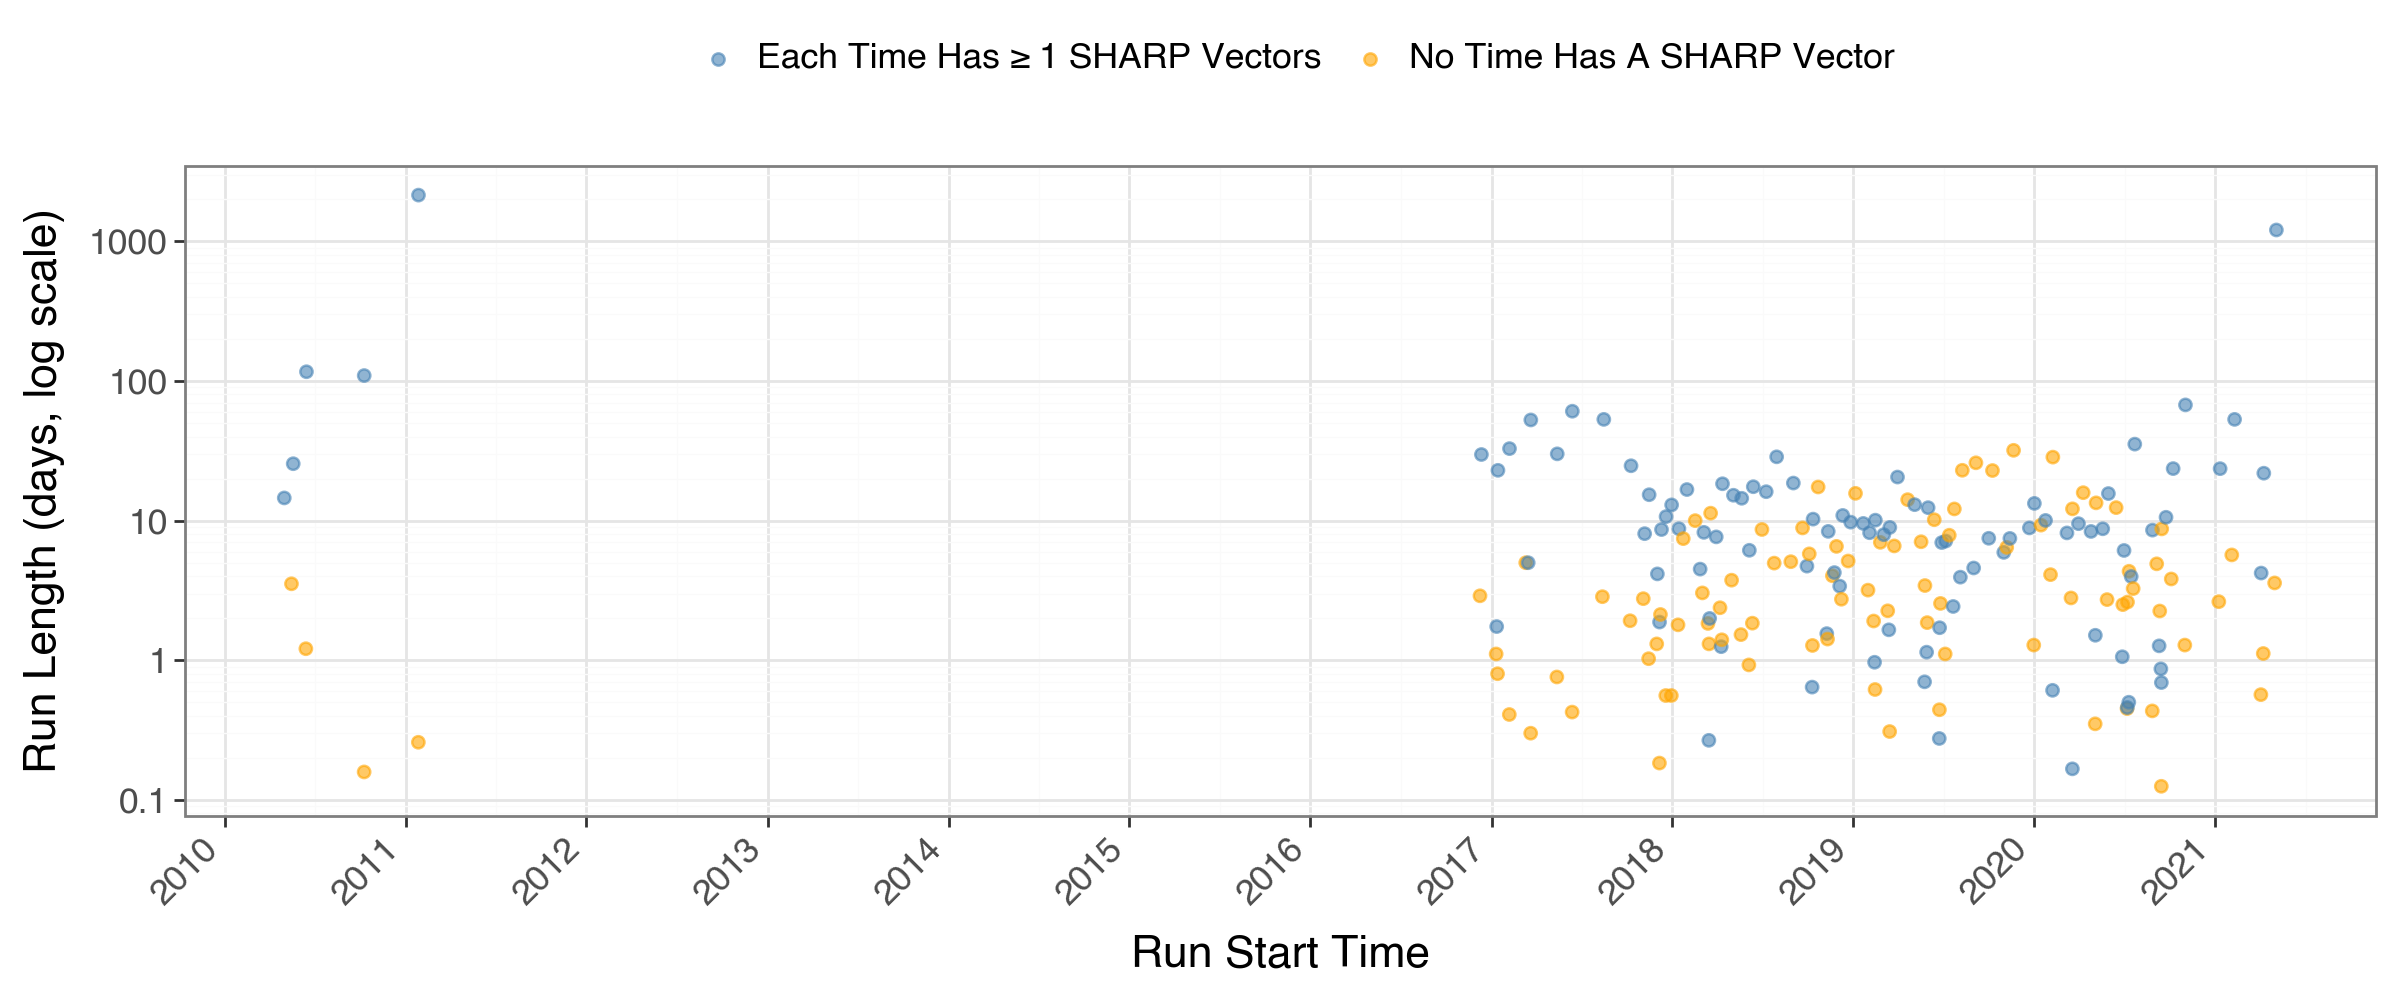

In [8]:
LABEL_WITH = "Each Time Has ≥ 1 SHARP Vectors"
LABEL_WITHOUT = "No Time Has A SHARP Vector"
COLORS = {LABEL_WITH: "steelblue", LABEL_WITHOUT: "orange"}

def run_plot(runs):
    plot_df = runs.copy()
    plot_df["duration_days"] = (
        plot_df["duration"].dt.total_seconds() / 86400
    )
    plot_df["type"] = plot_df["has_record"].map(
        {True: LABEL_WITH, False: LABEL_WITHOUT}
    )
    return (
        ggplot(
            plot_df,
            aes(x="start", y="duration_days", color="type"),
        )
        + geom_point(alpha=0.6, size=2)
        + scale_color_manual(values=COLORS)
        + scale_x_datetime(date_labels="%Y", date_breaks="1 year")
        + scale_y_log10()
        + labs(
            x="Run Start Time",
            y="Run Length (days, log scale)",
            color="",
        )
        + theme_bw(base_size=16)
        + theme(
            axis_text_x=element_text(rotation=45, hjust=1),
            legend_position="top",
            legend_key=element_blank(),
            figure_size=(12, 5),
        )
    )

# run_length_vs_start_time.png
run_plot(runs_any)

/Users/vkverma/research/harp_data/env/lib/python3.12/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


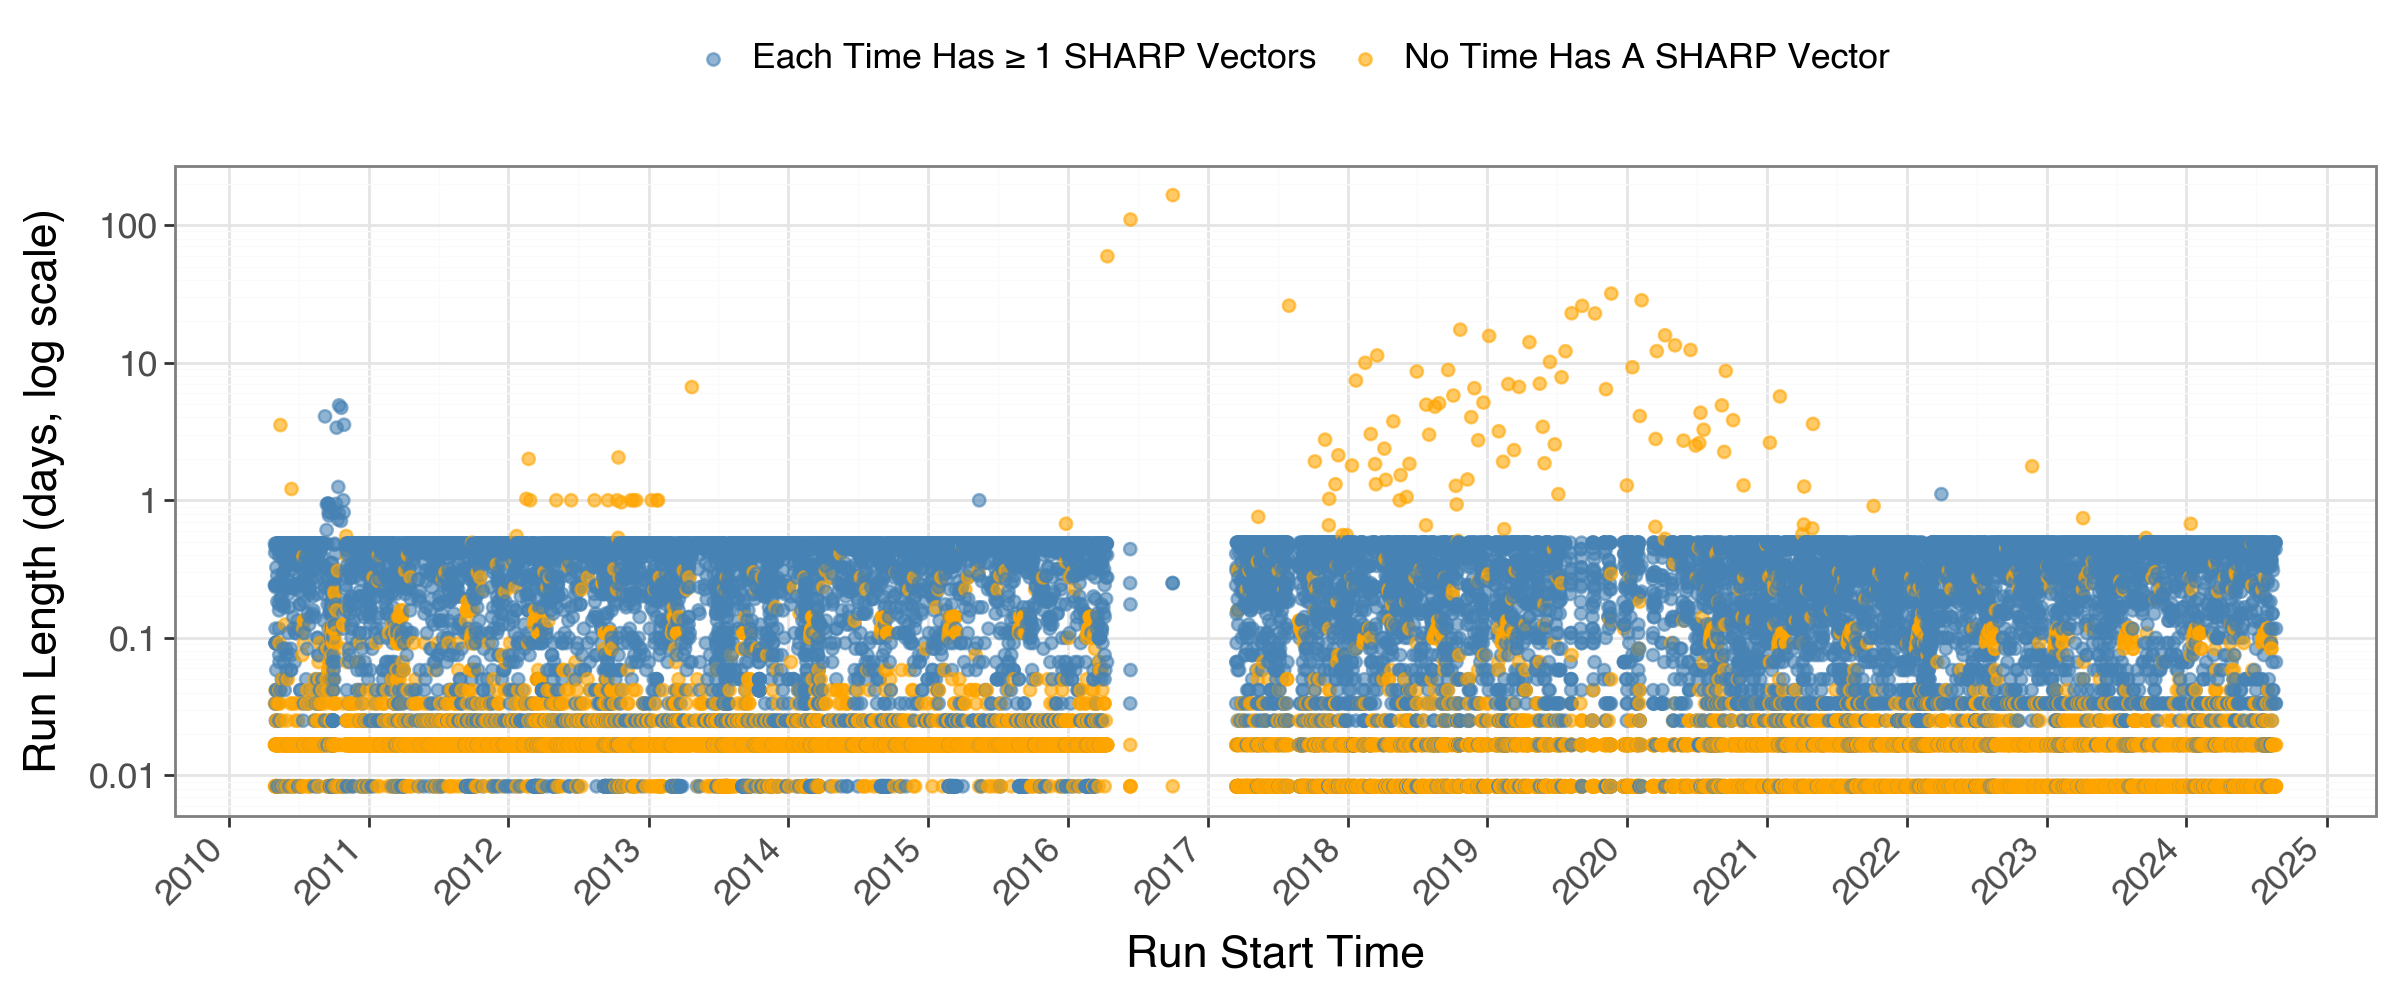

In [9]:
run_plot(runs_hq)

## 7. Five longest runs with records

In [10]:
print("=== Any record — 5 longest runs with records ===")
display(
    runs_any[runs_any["has_record"]]
    .sort_values("duration", ascending=False)
    .head(5)
    [["start", "end", "duration", "n_times"]]
    .reset_index(drop=True)
)

print("\n=== HQ record — 5 longest runs with records ===")
display(
    runs_hq[runs_hq["has_record"]]
    .sort_values("duration", ascending=False)
    .head(5)
    [["start", "end", "duration", "n_times"]]
    .reset_index(drop=True)
)

=== Any record — 5 longest runs with records ===


,start,end,duration,n_times
0,2011-01-26 22:00:00+00:00,2016-12-08 14:48:00+00:00,2142 days 17:00:00,257125
1,2021-05-04 05:12:00+00:00,2024-08-21 23:48:00+00:00,1205 days 18:48:00,144694
2,2010-06-14 19:12:00+00:00,2010-10-09 04:24:00+00:00,116 days 09:24:00,13967
3,2010-10-09 08:24:00+00:00,2011-01-26 15:36:00+00:00,109 days 07:24:00,13117
4,2020-11-01 15:48:00+00:00,2021-01-08 00:12:00+00:00,67 days 08:36:00,8083



=== HQ record — 5 longest runs with records ===


,start,end,duration,n_times
0,2010-10-15 21:00:00+00:00,2010-10-20 18:24:00+00:00,4 days 21:36:00,588
1,2010-10-21 12:00:00+00:00,2010-10-26 04:48:00+00:00,4 days 17:00:00,565
2,2010-09-09 01:36:00+00:00,2010-09-13 03:12:00+00:00,4 days 01:48:00,489
3,2010-10-28 17:00:00+00:00,2010-11-01 05:48:00+00:00,3 days 13:00:00,425
4,2010-10-09 08:48:00+00:00,2010-10-12 17:36:00+00:00,3 days 09:00:00,405


## 8. Record quality flags

In [11]:
SHARP_PARAMS = [
    "USFLUX", "MEANGAM", "MEANGBT", "MEANGBZ", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH", "TOTUSJH",
    "ABSNJZH", "SAVNCPP", "MEANPOT", "TOTPOT", "MEANSHR", "SHRGT45",
]

sharp = df[SHARP_PARAMS]
n_missing = sharp.isna().sum(axis=1)

df["flag_all_missing"] = n_missing == len(SHARP_PARAMS)
df["flag_some_missing"] = (
    (n_missing > 0) & (n_missing < len(SHARP_PARAMS))
)
df["flag_low_quality"] = (df["QUALITY"] != 0).fillna(False)

for col in [
    "flag_all_missing", "flag_some_missing", "flag_low_quality",
]:
    print(f"{col}: {df[col].sum():,}")

flag_all_missing: 334,403
flag_some_missing: 5,055
flag_low_quality: 354,307


In [12]:
# When all params are missing, treat low-quality as N/A
lq_disp = np.where(
    df["flag_all_missing"], "N/A",
    np.where(df["flag_low_quality"], "Yes", "No"),
)

summary = (
    pd.DataFrame({
        "missing":     df["flag_all_missing"].map(
            {True: "Yes", False: "No"}
        ),
        "incomplete":  df["flag_some_missing"].map(
            {True: "Yes", False: "No"}
        ),
        "low_quality": lq_disp,
    })
    .groupby(["missing", "incomplete", "low_quality"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)
summary["pct"] = (
    (summary["n"] / len(df) * 100).round(0).astype(int)
)
display(summary)

def fmt_pct(p):
    if p == 0:
        return r"$\approx$ 0\%"
    return rf"{p}\%"

rows = []
for _, r in summary.iterrows():
    cells = " & ".join([
        r["missing"],
        r["incomplete"],
        r["low_quality"],
        f"{r['n']:,}",
        fmt_pct(r["pct"]),
    ])
    rows.append(f"        {cells} \\\\")
    rows.append("        \\hline")

print("\n".join(rows))

,missing,incomplete,low_quality,n,pct
0,No,No,No,3466955,83
1,No,No,Yes,353867,9
2,Yes,No,N/A,334403,8
3,No,Yes,No,4615,0
4,No,Yes,Yes,440,0


        No & No & No & 3,466,955 & 83\% \\
        \hline
        No & No & Yes & 353,867 & 9\% \\
        \hline
        Yes & No & N/A & 334,403 & 8\% \\
        \hline
        No & Yes & No & 4,615 & $\approx$ 0\% \\
        \hline
        No & Yes & Yes & 440 & $\approx$ 0\% \\
        \hline
